# 02 · 실제 chunk length–latency와 포화점의 식별

## 검증할 명제

$\ell$은 4 KiB로 정렬된 저장 행의 수다. 원점에서 $(\ell,T(\ell))$로 가는 직선의 기울기와 throughput의 관계는

$$\rho(\ell)=T(\ell)/\ell,\qquad B(\ell)=4096\ell/T(\ell),\qquad
\arg\min\rho=\arg\max B.$$

이는 정의로부터의 항등식이다. **유한한 최적 길이의 존재**, **최초 포화점의 유일성**, **전후 두 직선 적합성**은 항등식이 아니라 측정할 가설이다. 예를 들어 $T(\ell)=a+b\ell$이면 $\rho=b+a/\ell$은 계속 감소해 유한 최소점이 없다.

## fresh 측정과 단위

각 실행에서 대상 filesystem에 512 MiB 난수 파일을 새로 쓰고 `fsync`한 뒤 Linux `O_DIRECT + preadv`로 읽는다. 4 KiB–8 MiB chunk를 측정하며 가장 큰 chunk도 batch 64개를 서로 다른 위치에서 읽도록 파일 크기를 정한다. 정렬된 버퍼를 사용하고 direct I/O 실패 시 중단한다. `/tmp` 같은 tmpfs는 SSD로 측정하지 않는다. 파일은 실행 후 삭제한다. 이는 page cache를 우회하지만 SSD controller cache까지 제거하는 실험은 아니다.

workers $p=4$, batch size $q\in\{1,8,32,64\}$, 서로 다른 offset들을 사용한다. 같은 반복 안에서 $(\ell,q)$ 순서를 무작위화한다. 7개 독립 반복 블록의 원시 시간 $t_{\ell,q,b}$를 모두 저장한다.

$$\widehat T_q(\ell)=\operatorname{median}_b(t_{\ell,q,b})/q.$$

이는 thread dispatch·Python 호출·completion을 포함한 **batch당 상각 비용**이다. 단일 read의 service time도, 논문의 C++/Jetson 성능 재현도 아니다. $q=64$를 기본 모델로 쓰되 $q=32$와의 차이를 반드시 표시한다. batch plateau가 확인되지 않으면 “포화 latency table”이라고 단정하지 않는다.

## 최소점과 plateau의 구별

측정한 길이 집합 $\mathcal G$에 대해서만

$$\hat s_{\min}=\arg\min_{\ell\in\mathcal G}\widehat T_{64}(\ell)/\ell,\qquad
\hat s_\varepsilon=\min\{\ell\in\mathcal G:\hat\rho(\ell)\le(1+\varepsilon)\min\hat\rho\},\quad\varepsilon=.05.$$

최대 throughput의 99% 기준은 $\rho\le\rho_{\min}/.99$와 같고 $\varepsilon=.05$와는 다른 정의다. 위 $s_\varepsilon$는 near-best 집합의 첫 원소이지 이후 모든 길이가 plateau라는 보장은 아니다. 최소점이 측정 상한에 붙거나 bootstrap 분포가 넓으면 범위를 넓혀야 한다. 상한을 포화점이라고 자동 대입하지 않는다.

반복 block을 길이 전체에 걸쳐 함께 bootstrap한다. 매 복제마다 median, 최소점, near-best 길이를 다시 계산한다. argmin의 선택 편향과 다중 후보 경쟁 때문에 한 점의 작은 오차막대를 포화점의 확신으로 해석하지 않는다.

## 두 직선 가설의 경쟁 모델

$$
\begin{aligned}
T_A(\ell)&=a+b\ell,\\
T_H(\ell)&=a+b\ell+d(\ell-s)_+,\\
T_S(\ell)&=b_1\ell+d\max(s,\ell),\quad b_1,d\ge0.
\end{aligned}
$$

$T_H$는 연속 hinge이지만 기울기·절편을 강제하지 않는다. $T_S$는 다음의 강한 plateau 가설이다.

$$T_S(\ell)=\begin{cases}ds+b_1\ell&\ell\le s,\\(b_1+d)\ell&\ell>s.\end{cases}
\quad \frac{T_S(\ell)}\ell=b_1+d\max(s/\ell,1).$$

따라서 $\ell\ge s$의 모든 점이 최소 기울기를 갖는다. “포화점만이 유일한 최적 길이”라는 결론은 나오지 않는다. $d=0$이면 모든 길이의 효율이 같다. $T_S(0)=0$은 별도로 정의한다.

처음 4개 반복의 median으로 계수와 $s$를 선택한다. 남은 3개 반복에는 **계수와 breakpoint를 다시 맞추지 않는다**. 검증 RMSE·상대오차와 residual plot으로 가설을 비교한다. $s$는 양쪽에 측정점이 남는 interior grid만 탐색한다. 모델의 in-sample $R^2$만으로 두 직선을 채택하지 않는다.

## 출력과 해석

길이–latency 오차막대, 원점 접선, $T/\ell$, batch 수별 throughput, holdout residual, bootstrap 포화점 분포를 같은 노트북에 둔다. 원시 CSV와 mount·seed·workers·소스 hash를 실행별 디렉토리에 남긴다. 다른 노트북은 이 결과를 읽지 않고 필요한 측정을 새로 수행한다.

측정 범위를 벗어난 값은 외삽하지 않는다. 행 크기 변경은 $s_{rows}=s_{bytes}/bytes_{row}$로 환산해야 하며, 4 KiB 실험의 행 수를 원본 모델의 채널 수와 자동으로 동일시할 수 없다.


## 실행 설정과 provenance

Run All은 새로운 계산·측정을 수행하고 고유 run 디렉토리를 만듭니다.

In [1]:
from pathlib import Path
import json
import sys
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p / "conclusion_september" for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "conclusion_september/core.py").exists())
sys.path.insert(0, str(ROOT))
import core as C
from reporting import begin, figure, finish
SEED = 20260926
rng = np.random.default_rng(SEED)
RUN = begin(ROOT, "02_chunk_latency", SEED)

**이번 실행:** `02_chunk_latency-20260926T043627-2e511c9d` · seed `20260926` · 새 계산/측정

## 측정 · 새로운 파일, 무작위 순서, 원시 반복값

In [2]:
from measure import profile
from scipy.optimize import nnls
REPEATS, EPSILON = 7, .05
lengths = np.unique(np.r_[np.arange(1, 17), [20, 24, 32, 40, 48, 64, 80, 96, 128, 160, 192, 256, 384, 512, 768, 1024, 1536, 2048]])
raw, hardware = profile(RUN, lengths=lengths, repeats=REPEATS, seed=SEED)
raw.to_csv(RUN / "io_raw.csv", index=False)
(RUN / "hardware.json").write_text(json.dumps(hardware, indent=2))
data = raw[raw["count"] == raw["count"].max()]
wide = data.pivot(index="length", columns="repeat", values="per_chunk_ms").sort_index()
x = wide.index.to_numpy(dtype=float)
samples = wide.to_numpy()
y = np.median(samples, axis=1)
train, holdout = np.median(samples[:, :4], axis=1), np.median(samples[:, 4:], axis=1)
ratio = y / x
s_min = int(x[ratio.argmin()])
s_near = int(x[np.flatnonzero(ratio <= (1 + EPSILON) * ratio.min())[0]])
display(pd.DataFrame({"length_pages": x, "median_ms": y, "ms_per_page": ratio}).round(6))
display(hardware)

,length_pages,median_ms,ms_per_page
0,1.0,0.023855,0.023855
1,2.0,0.028240,0.014120
2,3.0,0.025822,0.008607
3,4.0,0.030967,0.007742
4,5.0,0.027905,0.005581
5,6.0,0.030711,0.005118
6,7.0,0.035722,0.005103
7,8.0,0.032654,0.004082
8,9.0,0.034693,0.003855
9,10.0,0.037053,0.003705


{'mount': {'source': '/dev/nvme0n1p3[/home]',
  'fstype': 'btrfs',
  'target': '/home'},
 'direct': True,
 'page_bytes': 4096,
 'blob_mib': 512,
 'workers': 4,
 'seed': 20260926,
 'repeats': 7,
 'counts': [1, 8, 32, 64],
 'platform': 'Linux-7.2.5-200.fc44.x86_64-x86_64-with-glibc2.43',
 'timer': 'perf_counter_ns; dispatch+completion',
 'regime': 'largest measured batch; saturation must be checked'}

## 推定 · 반복 단위 bootstrap과 train-only breakpoint 선택

In [3]:
bootstrap = []
for _ in range(400):
    draw = rng.integers(0, REPEATS, REPEATS)
    boot_ratio = np.median(samples[:, draw], axis=1) / x
    bootstrap.append((x[boot_ratio.argmin()], x[np.flatnonzero(boot_ratio <= 1.05 * boot_ratio.min())[0]]))
bootstrap = np.asarray(bootstrap)
boot_frame = pd.DataFrame(bootstrap, columns=["minimum_pages", "near_best_pages"])
boot_frame.to_csv(RUN / "bootstrap.csv", index=False)

def design(kind, s=None):
    if kind == "Affine":
        return np.column_stack([np.ones_like(x), x])
    if kind == "Hinge":
        return np.column_stack([np.ones_like(x), x, np.maximum(0, x - s)])
    return np.column_stack([x, np.maximum(s, x)])

models, model_rows = {}, []
for kind in ["Affine", "Hinge", "Plateau two-line"]:
    best = None
    for s in ([None] if kind == "Affine" else x[3:-3]):
        X = design(kind, s)
        coef = nnls(X, train)[0] if kind == "Plateau two-line" else np.linalg.lstsq(X, train, rcond=None)[0]
        prediction = X @ coef
        error = np.mean((prediction - train)**2)
        if best is None or error < best[0]:
            best = error, s, coef, prediction
    error, s, coef, prediction = best
    models[kind] = prediction
    model_rows.append(dict(model=kind, breakpoint_pages=s, coefficients=coef.tolist(),
                           train_rmse=np.sqrt(error), holdout_rmse=np.sqrt(np.mean((prediction - holdout)**2)),
                           holdout_mape=100 * np.mean(abs(prediction - holdout) / holdout)))
fits = pd.DataFrame(model_rows)
fits.to_csv(RUN / "fits.csv", index=False)
display(fits)

,model,breakpoint_pages,coefficients,train_rmse,holdout_rmse,holdout_mape
0,Affine,NaN,"[0.028102176098257967, 0.0005829266461525213]",0.008176,0.008789,7.459065
1,Hinge,160.0,"[0.02515746097196333, 0.0006481508061603718, -...",0.007403,0.008014,10.116060
2,Plateau two-line,768.0,"[0.0005642684615120184, 3.811375368216571e-05]",0.008555,0.009449,6.515626


## 그림 · 원점 기울기, batch 수, validation residual, 최소점 불확실성

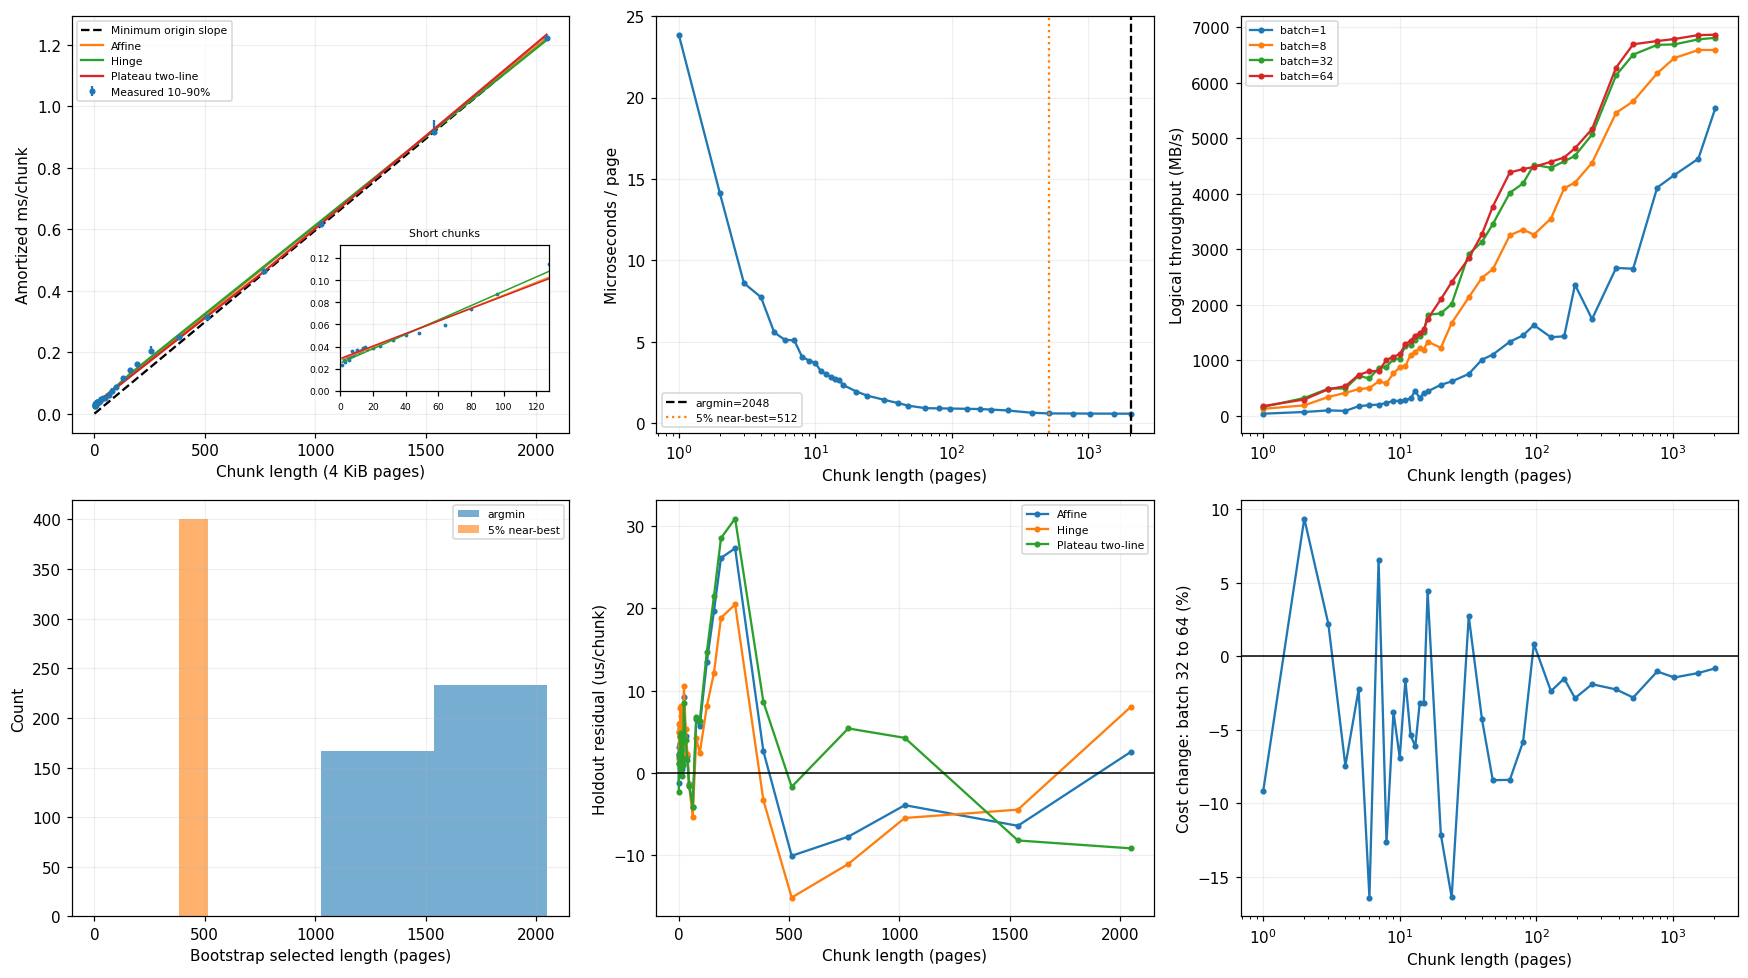

**실행에서 확인한 값**

- **argmin_pages**: 2048

- **near_best_pages**: 512

- **minimum_at_boundary**: True

- **bootstrap_90pct**: {'minimum_pages': {0.05: 1536.0, 0.95: 2048.0}, 'near_best_pages': {0.05: 512.0, 0.95: 512.0}}

- **best_holdout_model**: Hinge

- **median_abs_batch_change_pct**: 3.4763283787139887

- **scope**: Measured finite range, four Python reader workers; do not assume a saturated plateau

- **completed_utc**: 2026-09-26T04:36:34.192646+00:00

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
lo, hi = np.quantile(samples, [.1, .9], axis=1)
axes[0, 0].errorbar(x, y, yerr=[y - lo, hi - y], fmt=".", label="Measured 10–90%")
axes[0, 0].plot([0, x.max()], [0, ratio.min() * x.max()], "k--", label="Minimum origin slope")
for kind, prediction in models.items():
    axes[0, 0].plot(x, prediction, label=kind)
    axes[1, 1].plot(x, (holdout - prediction) * 1000, ".-", label=kind)
axes[0, 0].set(xlabel="Chunk length (4 KiB pages)", ylabel="Amortized ms/chunk")
axes[0, 1].plot(x, ratio * 1000, "o-", ms=3)
axes[0, 1].axvline(s_min, color="black", ls="--", label=f"argmin={s_min}")
axes[0, 1].axvline(s_near, color="tab:orange", ls=":", label=f"5% near-best={s_near}")
axes[0, 1].set(xlabel="Chunk length (pages)", ylabel="Microseconds / page")
for count, group in raw.groupby("count"):
    med = group.groupby("length").batch_ms.median()
    throughput = count * med.index * 4096 / med.values / 1000
    axes[0, 2].plot(med.index, throughput, ".-", label=f"batch={count}")
axes[0, 2].set(xlabel="Chunk length (pages)", ylabel="Logical throughput (MB/s)")
axes[1, 0].hist(bootstrap[:, 0], bins=np.r_[0, x + .5], alpha=.6, label="argmin")
axes[1, 0].hist(bootstrap[:, 1], bins=np.r_[0, x + .5], alpha=.6, label="5% near-best")
axes[1, 0].set(xlabel="Bootstrap selected length (pages)", ylabel="Count")
axes[1, 1].axhline(0, color="black", lw=1)
axes[1, 1].set(xlabel="Chunk length (pages)", ylabel="Holdout residual (us/chunk)")
q_table = raw.groupby(["length", "count"]).per_chunk_ms.median().unstack()
batch_change = 100 * (q_table[64] / q_table[32] - 1)
axes[1, 2].plot(batch_change.index, batch_change, ".-")
axes[1, 2].axhline(0, color="black", lw=1)
axes[1, 2].set(xlabel="Chunk length (pages)", ylabel="Cost change: batch 32 to 64 (%)")
zoom = axes[0, 0].inset_axes([.54, .1, .42, .35])
zoom.plot(x, y, ".", ms=3)
for prediction in models.values():
    zoom.plot(x, prediction, lw=1)
zoom.set(xlim=(0, 128), ylim=(0, y[x <= 128].max()*1.15), title="Short chunks")
zoom.tick_params(labelsize=6)
zoom.title.set_fontsize(7)
for ax in [axes[0, 1], axes[0, 2], axes[1, 2]]:
    ax.set_xscale("log")
for ax in axes.flat:
    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=7)
figure(RUN, "latency_model_audit")
finish(RUN, argmin_pages=s_min, near_best_pages=s_near,
       minimum_at_boundary=bool(s_min == x[-1]),
       bootstrap_90pct=boot_frame.quantile([.05, .95]).to_dict(),
       best_holdout_model=fits.loc[fits.holdout_rmse.idxmin(), "model"],
       median_abs_batch_change_pct=float(abs(batch_change).median()),
       scope="Measured finite range, four Python reader workers; do not assume a saturated plateau")